# Customer Churn Predictor — EDA & Feature Selection
**Introduction to Data Science | Final Project**

This notebook covers the full analytical pipeline:
1. Load raw GitHub user data from the saved JSON file
2. Exploratory Data Analysis
3. Feature generation (8 behavioral features)
4. Feature selection — all 4 methods (Filter, RFE, Decision Tree, Random Forest)
5. Comparison table with final keep/drop decisions
6. Train and save the final model to `app/model.pkl`

## 0 — Imports & Setup

In [1]:
import sys, os
sys.path.insert(0, "../app")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, RFE
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from scraper import load_raw_data, fetch_all_users
from features import generate_features, get_X_y, FEATURE_COLUMNS, check_class_balance
from model import train, save_model
from dotenv import load_dotenv

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", "{:.3f}".format)
print("Imports OK")

Imports OK


## 1 — Load Raw Data

We load directly from the saved JSON file if no Github API is present in the `.env` file (not present in the repo).

The `load_raw_data()` function in `scraper.py` handles both plain list and wrapped JSON structures.

In case there is a Github Token then the `fetch_all_users` function is called also from `scraper.py`.

In [2]:
df_raw = load_raw_data("../data/raw/users_raw.json")
print(f"Shape: {df_raw.shape}")
df_raw.head()

[scraper] Loaded 630 records from ../data/raw/users_raw.json
[scraper] Null counts:
username          0
followers         0
following         0
public_repos      0
public_gists      0
created_at        0
updated_at        0
bio             549
dtype: int64

Shape: (630, 8)


,username,followers,following,public_repos,public_gists,created_at,updated_at,bio
0,mojombo,24628,11,66,62,2007-10-20 05:24:19+00:00,2026-05-29 01:54:43+00:00,None
1,defunkt,22703,215,107,274,2007-10-20 05:24:19+00:00,2025-08-08 19:18:26+00:00,🍔
2,pjhyett,8402,30,8,21,2008-01-07 17:54:22+00:00,2026-04-07 17:46:52+00:00,None
3,wycats,10304,13,316,767,2008-01-12 05:38:33+00:00,2026-06-04 04:46:55+00:00,None
4,ezmobius,609,13,22,106,2008-01-12 07:51:46+00:00,2026-05-22 11:32:36+00:00,None


## 2 — Exploratory Data Analysis

Before generating features, we inspect the raw data for missing values,
data types, and basic distributions.

In [3]:
print("=== Data Types ===")
print(df_raw.dtypes)
print()
print("=== Null Counts ===")
print(df_raw.isnull().sum())
print()
print("=== Basic Stats ===")
df_raw.describe()

=== Data Types ===
username                     object
followers                     int64
following                     int64
public_repos                  int64
public_gists                  int64
created_at      datetime64[ns, UTC]
updated_at      datetime64[ns, UTC]
bio                          object
dtype: object

=== Null Counts ===
username          0
followers         0
following         0
public_repos      0
public_gists      0
created_at        0
updated_at        0
bio             549
dtype: int64

=== Basic Stats ===


,followers,following,public_repos,public_gists
count,630.000,630.000,630.000,630.000
mean,244.878,8.173,20.076,14.989
std,2035.256,34.939,54.048,68.330
min,0.000,0.000,0.000,0.000
25%,0.000,0.000,0.000,0.000
50%,0.000,0.000,1.000,0.000
75%,7.000,2.000,12.000,0.000
max,33205.000,642.000,691.000,1115.000


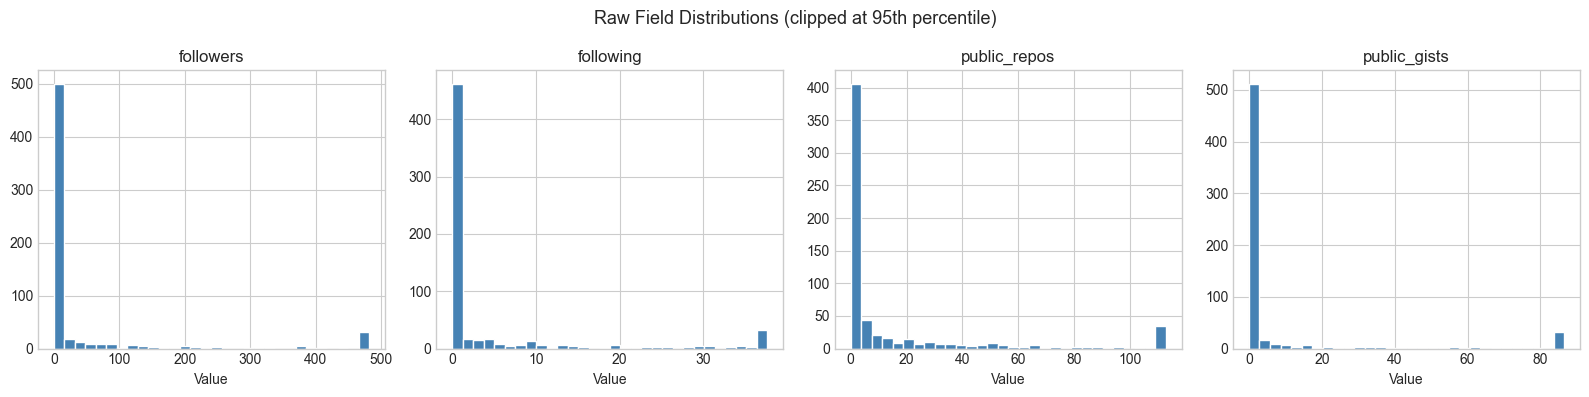

In [4]:
# Distribution of raw numeric fields
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, ["followers", "following", "public_repos", "public_gists"]):
    ax.hist(df_raw[col].clip(upper=df_raw[col].quantile(0.95)), bins=30,
            color="steelblue", edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel("Value")

plt.suptitle("Raw Field Distributions (clipped at 95th percentile)", fontsize=13)
plt.tight_layout()
plt.show()

In [5]:
# Bio fill rate
bio_rate = df_raw["bio"].notna().mean()
print(f"Users with a bio: {bio_rate:.1%}")
print(f"Users without a bio: {1 - bio_rate:.1%}")

Users with a bio: 12.9%
Users without a bio: 87.1%


## 3 — Feature Generation

Raw API fields are not features. We transform them into 8 behavioral signals
that encode domain knowledge about GitHub engagement patterns.

| Feature | Type | Reasoning |
|---|---|---|
| `days_since_last_activity` | Time-based | Primary recency signal |
| `account_age_days` | Time-based | Context for all other features |
| `follower_ratio` | Ratio | Social embeddedness |
| `inactive_ratio` | Ratio | Proportion of account life that's silent |
| `repos_per_year` | Aggregation | Productivity normalised by tenure |
| `total_engagement_score` | Aggregation | Composite volume signal |
| `has_no_repos` | Binary | Never onboarded properly |
| `has_bio` | Binary | Profile investment = lower churn risk |

In [6]:
X, y = get_X_y(df_raw)
check_class_balance(y)
print(f"\nFeature matrix shape: {X.shape}")
X.describe()

[features] Class balance:
  Retained (0): 266 (42.2%)
  Churned  (1): 364 (57.8%)
[features] Class balance looks healthy.

Feature matrix shape: (630, 8)


,days_since_last_activity,account_age_days,follower_ratio,inactive_ratio,repos_per_year,total_engagement_score,has_no_repos,has_bio
count,630.000,630.000,630.000,630.000,630.000,630.000,630.000,630.000
mean,1436.754,4274.143,15.307,0.429,1.284,279.943,0.402,0.129
std,1413.942,1752.570,109.199,0.405,3.069,2073.371,0.491,0.335
min,0.000,1570.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,67.000,2600.000,0.000,0.014,0.000,0.000,0.000,0.000
50%,1127.000,4713.000,0.000,0.349,0.135,2.000,0.000,0.000
75%,2600.000,5402.000,2.000,0.796,1.010,24.000,1.000,0.000
max,4944.000,6806.000,2052.333,1.000,37.607,33568.000,1.000,1.000


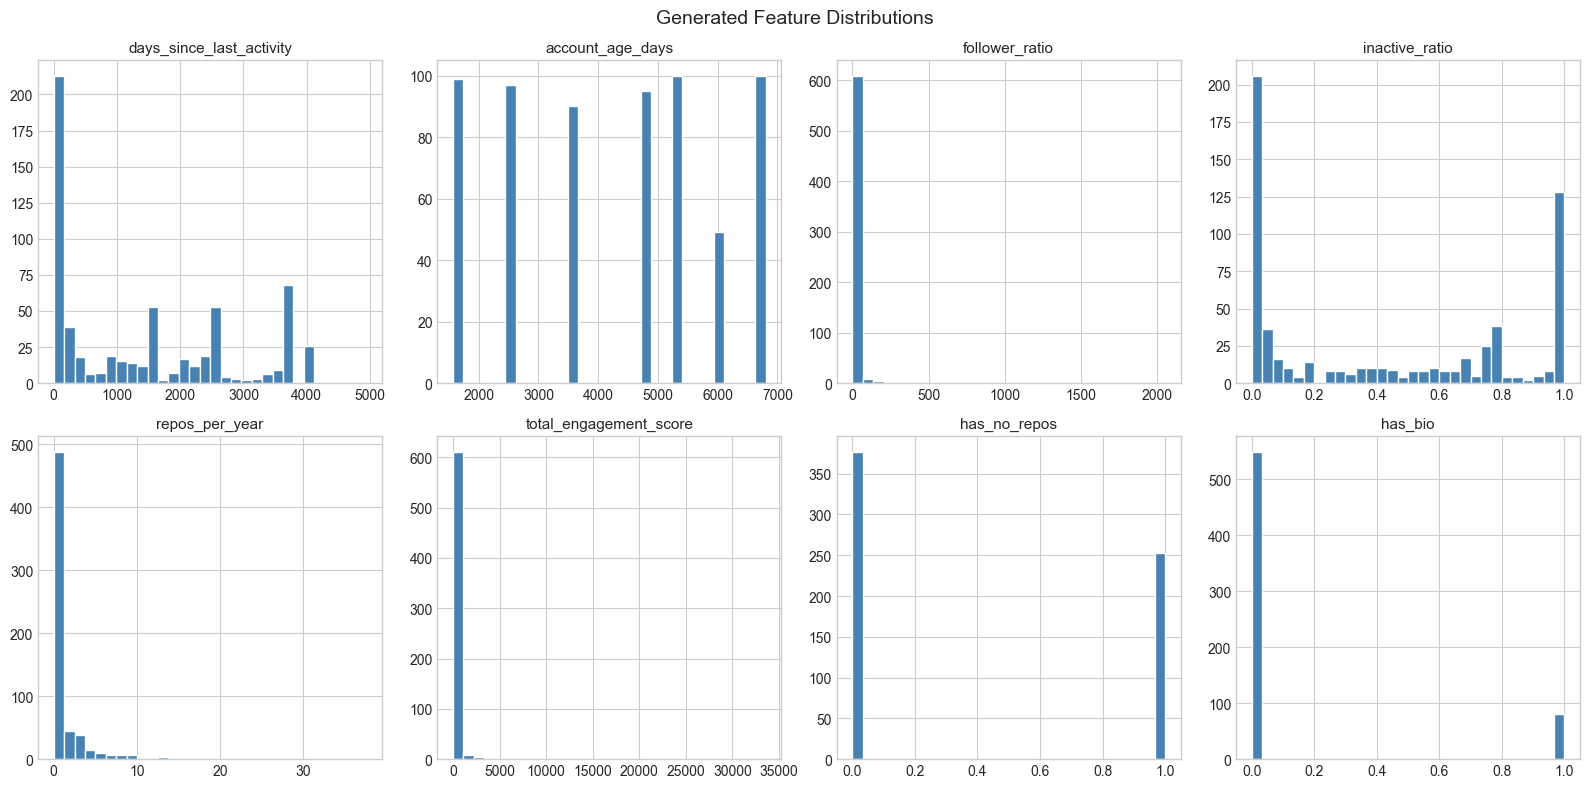

In [7]:
# Feature distributions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLUMNS):
    axes[i].hist(X[col], bins=30, color="steelblue", edgecolor="white")
    axes[i].set_title(col, fontsize=11)

plt.suptitle("Generated Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()

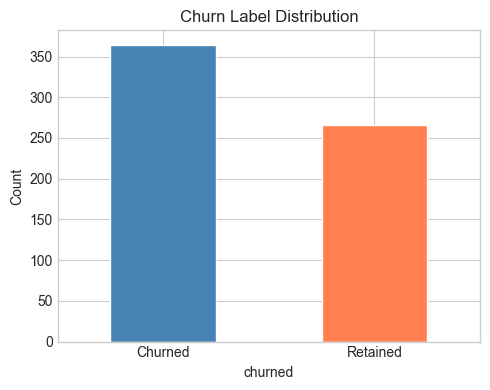

In [8]:
# Churn label distribution
fig, ax = plt.subplots(figsize=(5, 4))
y.value_counts().plot(kind="bar", ax=ax, color=["steelblue", "coral"], edgecolor="white")
ax.set_xticklabels([ "Churned","Retained"], rotation=0)
ax.set_ylabel("Count")
ax.set_title("Churn Label Distribution")
plt.tight_layout()
plt.show()

## 4 — Feature Selection

We split the data once and reuse the same split across all four methods for a fair comparison.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (504, 8) | Test: (126, 8)


### Method 1 — Filter Methods

Filter methods evaluate each feature **independently of any model**.
They are fast and ideal for removing obviously useless features before the more expensive methods run.

Three filters are applied:
- **Variance Threshold** — removes features that barely change across users
- **Correlation Matrix** — flags redundant feature pairs (corr > 0.9)
- **ANOVA F-test** — measures how much each feature's distribution differs between churned vs retained

In [10]:
# ── Variance Threshold ──────────────────────────────────────────────
sel_var = VarianceThreshold(threshold=0.01)
sel_var.fit(X_train)

low_var_features = X.columns[~sel_var.get_support()].tolist()
print(f"Features removed by variance threshold: {low_var_features or 'none — all features have sufficient variance'}")

Features removed by variance threshold: none — all features have sufficient variance


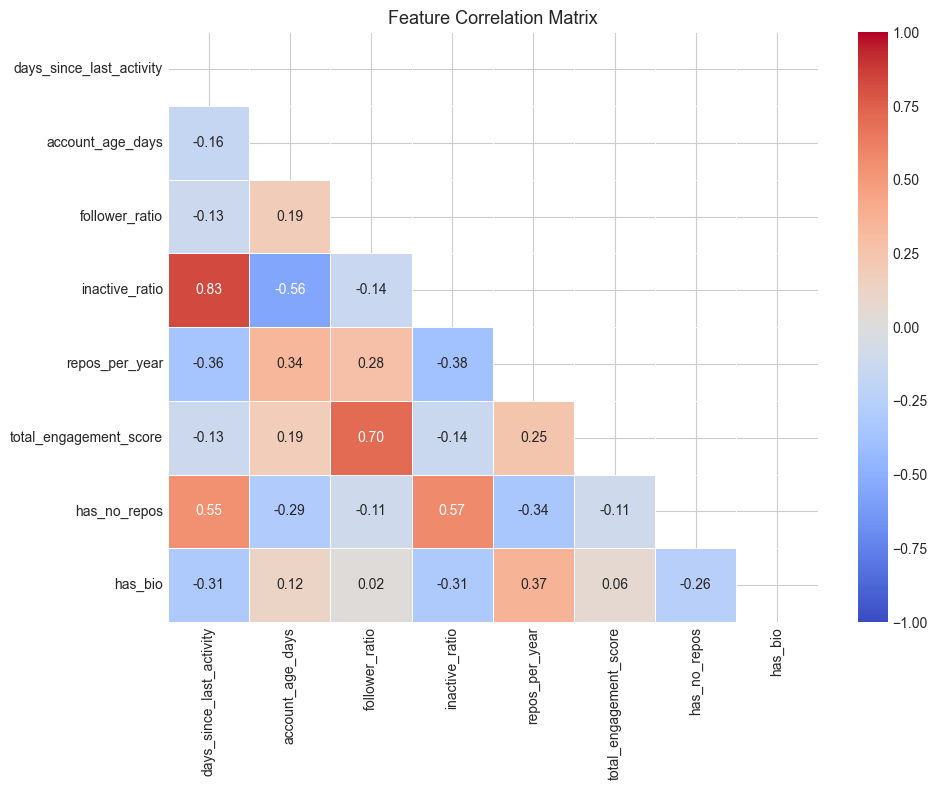

Highly correlated pairs (|r| > 0.9):
  None found.


In [11]:
# ── Correlation Matrix ──────────────────────────────────────────────
corr = X.corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            mask=mask, vmin=-1, vmax=1, linewidths=0.5)
plt.title("Feature Correlation Matrix", fontsize=13)
plt.tight_layout()
plt.show()

# Flag pairs above threshold
CORR_THRESHOLD = 0.9
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        val = corr.iloc[i, j]
        if abs(val) > CORR_THRESHOLD:
            high_corr_pairs.append((corr.index[i], corr.columns[j], round(val, 3)))

print(f"Highly correlated pairs (|r| > {CORR_THRESHOLD}):")
for pair in high_corr_pairs:
    print(f"  {pair[0]} — {pair[1]}: r = {pair[2]}")
if not high_corr_pairs:
    print("  None found.")

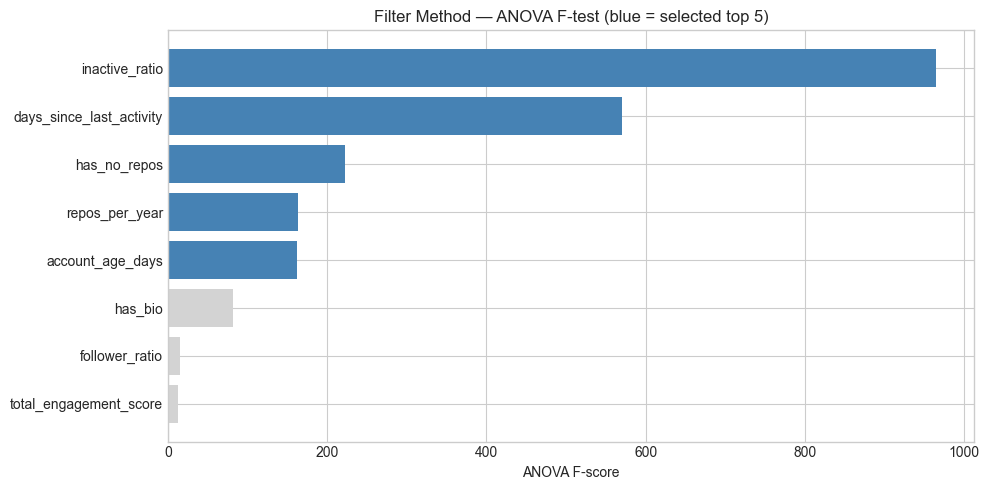

                 feature  f_score  p_value  selected  filter_rank
          inactive_ratio  964.186    0.000      True            1
days_since_last_activity  570.785    0.000      True            2
            has_no_repos  222.310    0.000      True            3
          repos_per_year  163.439    0.000      True            4
        account_age_days  161.468    0.000      True            5
                 has_bio   82.072    0.000     False            6
          follower_ratio   14.910    0.000     False            7
  total_engagement_score   12.590    0.000     False            8


In [12]:
# ── ANOVA F-test ────────────────────────────────────────────────────
sel_k = SelectKBest(score_func=f_classif, k=5)
sel_k.fit(X_train, y_train)

filter_df = pd.DataFrame({
    "feature":      FEATURE_COLUMNS,
    "f_score":      sel_k.scores_,
    "p_value":      sel_k.pvalues_,
    "selected":     sel_k.get_support(),
}).sort_values("f_score", ascending=False).reset_index(drop=True)

filter_df["filter_rank"] = range(1, len(filter_df) + 1)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["steelblue" if s else "lightgray" for s in filter_df["selected"]]
ax.barh(filter_df["feature"][::-1], filter_df["f_score"][::-1], color=colors[::-1])
ax.set_xlabel("ANOVA F-score")
ax.set_title("Filter Method — ANOVA F-test (blue = selected top 5)")
plt.tight_layout()
plt.show()

print(filter_df.to_string(index=False))

### Method 2 — Wrapper: Recursive Feature Elimination (RFE)

RFE trains a Logistic Regression, removes the weakest feature (by coefficient magnitude),
retrains, and repeats until the desired feature count is reached.
Unlike filters, RFE captures interactions between features because it uses an actual model.

In [13]:
lr = LogisticRegression(max_iter=1000, random_state=42)
rfe = RFE(estimator=lr, n_features_to_select=5, step=1)
rfe.fit(X_train, y_train)

rfe_df = pd.DataFrame({
    "feature":      FEATURE_COLUMNS,
    "rfe_selected": rfe.support_,
    "rfe_ranking":  rfe.ranking_,
}).sort_values("rfe_ranking").reset_index(drop=True)

print("RFE — Selected features:")
print(rfe_df[rfe_df["rfe_selected"]]["feature"].tolist())
print()
print(rfe_df.to_string(index=False))

RFE — Selected features:
['inactive_ratio', 'follower_ratio', 'has_no_repos', 'total_engagement_score', 'has_bio']

                 feature  rfe_selected  rfe_ranking
          inactive_ratio          True            1
          follower_ratio          True            1
            has_no_repos          True            1
  total_engagement_score          True            1
                 has_bio          True            1
          repos_per_year         False            2
days_since_last_activity         False            3
        account_age_days         False            4


### Method 3 — Decision Tree Feature Importance

A single Decision Tree scores features by how much they reduce Gini impurity at each split.
Features used near the root (early splits) get higher importance scores.

**Limitation:** a single tree is unstable — a different random seed or data split
can produce a very different ranking. Compare with Random Forest results.

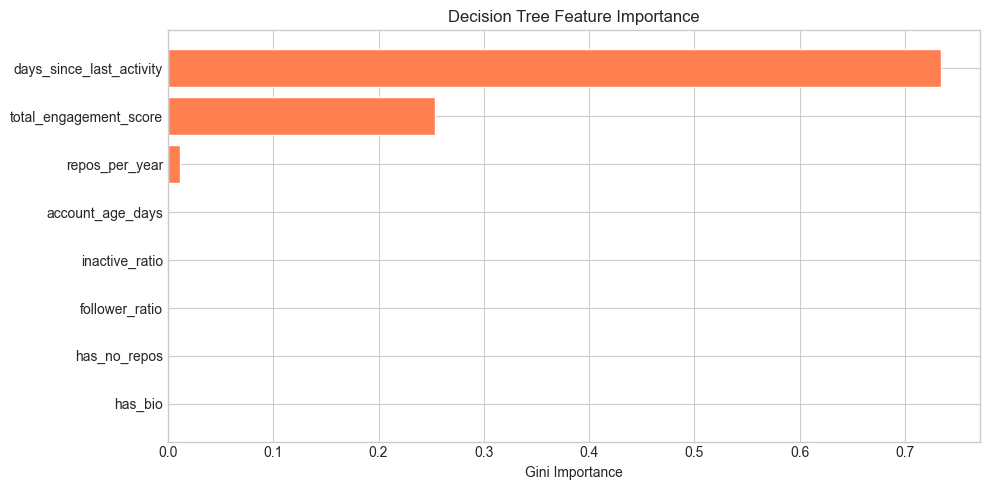

                 feature  dt_importance  dt_rank
days_since_last_activity          0.735        1
  total_engagement_score          0.254        2
          repos_per_year          0.012        3
        account_age_days          0.000        4
          inactive_ratio          0.000        5
          follower_ratio          0.000        6
            has_no_repos          0.000        7
                 has_bio          0.000        8


In [14]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

dt_df = pd.DataFrame({
    "feature":       FEATURE_COLUMNS,
    "dt_importance": dt.feature_importances_,
}).sort_values("dt_importance", ascending=False).reset_index(drop=True)

dt_df["dt_rank"] = range(1, len(dt_df) + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(dt_df["feature"][::-1], dt_df["dt_importance"][::-1], color="coral", edgecolor="white")
ax.set_xlabel("Gini Importance")
ax.set_title("Decision Tree Feature Importance")
plt.tight_layout()
plt.show()

print(dt_df.to_string(index=False))

### Method 4 — Random Forest Feature Importance

Random Forest trains 100 decision trees, each on a random bootstrap sample,
and **averages** their importance scores. This averaging makes the ranking
significantly more stable and trustworthy than a single Decision Tree.

If a feature ranks highly across all 100 trees, that's a robust signal.

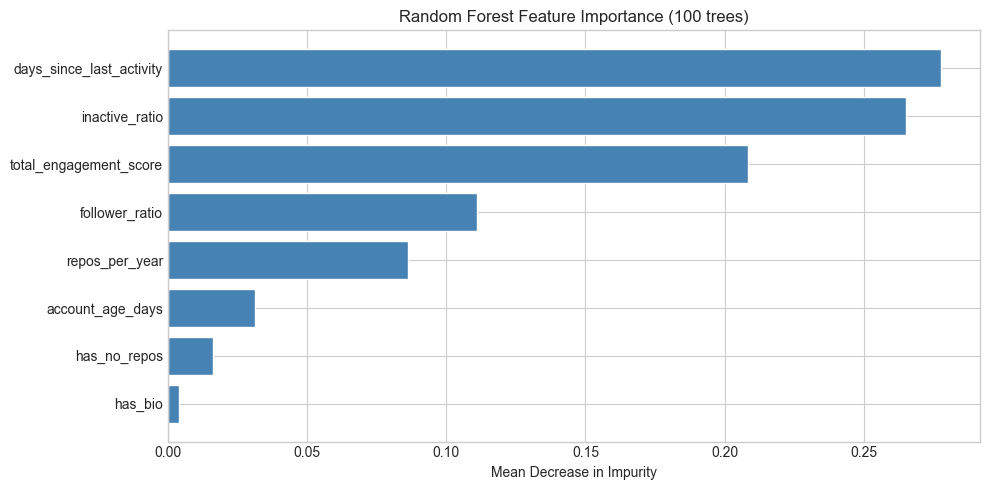

                 feature  rf_importance  rf_rank
days_since_last_activity          0.278        1
          inactive_ratio          0.265        2
  total_engagement_score          0.209        3
          follower_ratio          0.111        4
          repos_per_year          0.086        5
        account_age_days          0.031        6
            has_no_repos          0.016        7
                 has_bio          0.004        8


In [15]:
rf = RandomForestClassifier(
    n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

rf_df = pd.DataFrame({
    "feature":      FEATURE_COLUMNS,
    "rf_importance": rf.feature_importances_,
}).sort_values("rf_importance", ascending=False).reset_index(drop=True)

rf_df["rf_rank"] = range(1, len(rf_df) + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(rf_df["feature"][::-1], rf_df["rf_importance"][::-1], color="steelblue", edgecolor="white")
ax.set_xlabel("Mean Decrease in Impurity")
ax.set_title("Random Forest Feature Importance (100 trees)")
plt.tight_layout()
plt.show()

print(rf_df.to_string(index=False))

## 5 — Comparison Table

We now synthesise results from all four methods into a single table.
Features that rank highly **across all methods** are the strongest candidates to keep.
Disagreements between methods are the most analytically interesting findings.

In [16]:
comparison = pd.DataFrame({"feature": FEATURE_COLUMNS})

# Filter rank
comparison = comparison.merge(
    filter_df[["feature", "filter_rank"]], on="feature", how="left"
)

# RFE selected
comparison = comparison.merge(
    rfe_df[["feature", "rfe_selected"]], on="feature", how="left"
)
comparison["rfe_selected"] = comparison["rfe_selected"].map({True: "✅", False: "❌"})

# DT rank
comparison = comparison.merge(
    dt_df[["feature", "dt_rank"]], on="feature", how="left"
)

# RF rank
comparison = comparison.merge(
    rf_df[["feature", "rf_rank"]], on="feature", how="left"
)

# Decision logic
def decide(row):
    avg_rank = (row["filter_rank"] + row["dt_rank"] + row["rf_rank"]) / 3
    rfe_ok   = row["rfe_selected"] == "✅"
    if avg_rank <= 3 and rfe_ok:
        return "✅ Keep"
    elif avg_rank <= 5 or rfe_ok:
        return "⚠️  Optional"
    else:
        return "❌ Drop"

comparison["decision"] = comparison.apply(decide, axis=1)
comparison = comparison.sort_values("rf_rank").reset_index(drop=True)

print("=" * 72)
print("FEATURE SELECTION COMPARISON TABLE")
print("=" * 72)
comparison

FEATURE SELECTION COMPARISON TABLE


,feature,filter_rank,rfe_selected,dt_rank,rf_rank,decision
0,days_since_last_activity,2,❌,1,1,⚠️ Optional
1,inactive_ratio,1,✅,5,2,✅ Keep
2,total_engagement_score,8,✅,2,3,⚠️ Optional
3,follower_ratio,7,✅,6,4,⚠️ Optional
4,repos_per_year,4,❌,3,5,⚠️ Optional
5,account_age_days,5,❌,4,6,⚠️ Optional
6,has_no_repos,3,✅,7,7,⚠️ Optional
7,has_bio,6,✅,8,8,⚠️ Optional


In [17]:
# Highlight agreements and disagreements
kept     = comparison[comparison["decision"] == "✅ Keep"]["feature"].tolist()
optional = comparison[comparison["decision"] == "⚠️  Optional"]["feature"].tolist()
dropped  = comparison[comparison["decision"] == "❌ Drop"]["feature"].tolist()

print(f"Keep ({len(kept)}):     {kept}")
print(f"Optional ({len(optional)}): {optional}")
print(f"Drop ({len(dropped)}):     {dropped}")

Keep (1):     ['inactive_ratio']
Optional (7): ['days_since_last_activity', 'total_engagement_score', 'follower_ratio', 'repos_per_year', 'account_age_days', 'has_no_repos', 'has_bio']
Drop (0):     []


### Observations

Write your analysis here after running the cells above. Address these questions:

1. **Which feature ranked #1 across all methods?** What does that tell you about the primary driver of churn?
2. **Where did Filter and RFE disagree?** Filter methods ignore feature interactions; RFE captures them via the logistic regression model. A feature that's weak in isolation can gain power in combination.
3. **Where did DT and RF disagree?** If they conflict, trust RF — averaging 100 trees eliminates the variance of a single tree.
4. **Are any features highly correlated?** If so, which one did you drop and why?

## 6 — Train and Save Final Model

We now train on the **full dataset** (not just the train split) using the features
selected from the comparison table, then save to `app/model.pkl` for the Docker API.

In [18]:
final_model = train(df_raw, save=True)
print("\nmodel.pkl saved — ready for docker-compose up")

[model] Training on 630 samples | 364 churned, 266 retained

[model] Test set performance:
              precision    recall  f1-score   support

    Retained       0.98      1.00      0.99        53
     Churned       1.00      0.99      0.99        73

    accuracy                           0.99       126
   macro avg       0.99      0.99      0.99       126
weighted avg       0.99      0.99      0.99       126

[model] 5-fold cross-validation:
  accuracy: 0.975 ± 0.023
  f1: 0.978 ± 0.020
  precision: 0.982 ± 0.035
  recall: 0.975 ± 0.033

[model] Feature importances (Random Forest):
days_since_last_activity   0.278
inactive_ratio             0.265
total_engagement_score     0.209
follower_ratio             0.111
repos_per_year             0.086
account_age_days           0.031
has_no_repos               0.016
has_bio                    0.004

[model] Model saved to /home/alan/Desktop/Facu/Sem5/DataScience/churn-predictor/notebooks/../app/model.pkl

model.pkl saved — ready for docke

In [19]:
# Sanity check — simulate a /predict call end to end
from features import features_from_dict
from model import predict as model_predict

test_user = {
    "updated_at":   "2022-01-01T00:00:00Z",
    "created_at":   "2018-01-01T00:00:00Z",
    "followers":    5,
    "following":    50,
    "public_repos": 2,
    "public_gists": 0,
    "bio":          None,
}

feature_array = features_from_dict(test_user)
result = model_predict(final_model, feature_array)

print("Test user prediction:")
print(f"  Churned:           {result['churned']}")
print(f"  Churn probability: {result['churn_probability']}")
print()
print("If this matches your expectation (inactive user → high churn), the pipeline is working correctly.")

Test user prediction:
  Churned:           True
  Churn probability: 0.98

If this matches your expectation (inactive user → high churn), the pipeline is working correctly.


/home/alan/Desktop/Facu/Sem5/DataScience/churn-predictor/.venv/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alan/Desktop/Facu/Sem5/DataScience/churn-predictor/.venv/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
